# Clasificación de personajes de *Los Simpson* mediante un Perceptrón Multicapa (MLP)

**Evaluación Parcial N°1 — TLY1101 Técnicas Avanzadas de Machine Learning I**

| Ítem | Detalle |
|---|---|
| **Integrantes** | *Joaquin sanhueza, Carlos calvio, fernando guzman, vicente cossio* |
| **Sección / Docente** | *Seccion: 001-D Docente: Marco Japke* |
| **Dataset** | [`alfaro96/los-simpson`](https://www.kaggle.com/datasets/alfaro96/los-simpson) (Kaggle) |
| **Variante del grupo** | 5 personajes · 100 imágenes por clase · `SEED = 67` |
| **Entorno de ejecución** | Google Colab (no requiere GPU) |

---

> ### ⚠️ Cómo ejecutar este notebook
> `Entorno de ejecución → Reiniciar y ejecutar todo` (*Runtime → Restart and run all*).
>
> El notebook está diseñado para correr **de principio a fin sin modificaciones**. Todos los valores
> numéricos que aparecen en el análisis (accuracy, F1, épocas, cantidad de parámetros, etc.) se
> **imprimen desde el código**, de modo que el texto y los resultados no pueden quedar
> desincronizados entre una ejecución y otra.

### Índice

1. Introducción: problema de negocio, objetivos, KPIs y variante
2. Comprensión y exploración del conjunto de datos (EDA)
3. Preparación y preprocesamiento de los datos
4. Diseño del Perceptrón Multicapa
5. Entrenamiento del modelo y comparación de configuraciones
6. Evaluación del desempeño
7. Análisis de resultados y errores
8. Conclusiones
9. Consideraciones éticas
10. Artefactos generados

---
# 1. Introducción

## 1.1 Problema de negocio

Un archivo audiovisual que gestiona el catálogo de la serie *Los Simpson* necesita **etiquetar
automáticamente qué personaje aparece en cada fotograma**. Hoy ese etiquetado se hace de forma
manual, lo que resulta inviable a escala: solo el conjunto de datos con el que trabajamos contiene
más de 16.000 imágenes ya recortadas, y el catálogo completo de la serie supera las 700 emisiones.

Disponer de un clasificador automático de personajes habilita tres capacidades de negocio:

1. **Búsqueda por personaje** dentro del catálogo ("mostrar escenas donde aparece Bart").
2. **Generación automática de clips y miniaturas** centrados en un personaje.
3. **Métricas de tiempo en pantalla** por personaje, útiles para decisiones editoriales y de
   licenciamiento de merchandising.

El problema técnico asociado es de **clasificación supervisada multiclase sobre imágenes**.

## 1.2 Objetivos del proyecto

**Objetivo general**

> Evaluar la viabilidad de un **Perceptrón Multicapa (MLP)** como modelo de línea base para la
> clasificación automática de personajes de *Los Simpson*, caracterizando su desempeño y sus
> limitaciones antes de escalar a arquitecturas más especializadas.

**Objetivos específicos**

1. Explorar y caracterizar el conjunto de datos, identificando su distribución de clases y su calidad.
2. Definir y aplicar un preprocesamiento reproducible que permita alimentar una red densa.
3. Diseñar e implementar una arquitectura MLP justificando capas, activaciones e hiperparámetros.
4. Entrenar y validar el modelo, comparando el efecto de distintas configuraciones.
5. Evaluar el desempeño con métricas de clasificación e interpretar los resultados.
6. Auditar los errores del modelo e identificar las limitaciones estructurales del MLP en imágenes.

## 1.3 KPIs del proyecto

Los KPIs traducen el objetivo de negocio a umbrales medibles. La línea base de referencia es el
**azar: 1/5 = 20 %** de acierto, porque el subconjunto está perfectamente balanceado.

| KPI | Métrica | Umbral objetivo | Por qué este KPI |
|---|---|---|---|
| **KPI-1** | Accuracy en validación | **≥ 60 %** | Mínimo para que el etiquetado automático ahorre trabajo humano en vez de generarlo. |
| **KPI-2** | F1-Score macro | **≥ 0,55** | Al promediar por clase sin ponderar, impide que un buen resultado global esconda clases mal resueltas. |
| **KPI-3** | Recall mínimo por clase | **≥ 0,30** | Garantiza cobertura: ningún personaje puede quedar prácticamente invisible para el buscador. |
| **KPI-4** | Tiempo de entrenamiento | **< 5 min en Colab sin GPU** | Viabilidad operativa para reentrenar el modelo con frecuencia. |

> **Criterio de éxito del proyecto.** El objetivo **no es superar los KPIs a toda costa**, sino
> medir con rigor si un MLP los alcanza. Si un KPI no se cumple, ese resultado es igualmente válido
> y constituye el hallazgo central del estudio: sirve para justificar técnicamente el paso a una
> arquitectura convolucional en la siguiente experiencia de aprendizaje. Lo que se evalúa es la
> **calidad del análisis**, no la magnitud de la métrica.

## 1.4 Justificación de la selección del dataset

Entre los cuatro conjuntos propuestos se escogió **Los Simpson** por cuatro razones técnicas:

1. **Clases visualmente muy similares.** Bart, Lisa y Milhouse comparten paleta cromática (amarillo
   de piel y pelo, tonos cálidos de ropa) y proporciones. Esto somete a máxima tensión la principal
   debilidad del MLP —la pérdida de la estructura espacial al aplanar la imagen— y permite
   documentarla con evidencia, que es justamente el objetivo de la evaluación.
2. **Desbalance de clases real y pronunciado.** Obliga a tomar y justificar una decisión explícita
   de muestreo, en vez de recibir los datos ya equilibrados.
3. **Resolución variable y fondos heterogéneos.** Exige un preprocesamiento genuino
   (redimensionado, conversión de espacio de color, normalización) y no solo cargar tensores listos.
4. **Volumen manejable.** Permite iterar y comparar varias configuraciones dentro de las 5 horas
   asignadas, sin necesidad de GPU.

> **Nota sobre la ficha del dataset.** El documento de la evaluación describe este conjunto como
> "reconocer letras del lenguaje de señas, 42 clases, ~20.000 imágenes". Al inspeccionar la
> descarga real verificamos que corresponde a personajes de *Los Simpson*, con **25 clases** y
> **16.137 imágenes** en la carpeta `train/`. Trabajamos con las cifras medidas directamente sobre
> los datos, que se calculan en la sección 2.

## 1.5 Variante propia del grupo

Para diferenciar el trabajo del de otros grupos se definió la siguiente variante, fijada antes de
cualquier experimento:

| Decisión | Valor | Justificación |
|---|---|---|
| **Clases seleccionadas** | `homer_simpson`, `ned_flanders`, `lisa_simpson`, `bart_simpson`, `milhouse_van_houten` | Combina dos personajes cromáticamente distintivos (Homero, Ned) con tres altamente similares entre sí (Bart, Lisa, Milhouse), para contrastar casos fáciles y difíciles. |
| **Imágenes por clase** | 100 (500 en total) | Muestreo balanceado que neutraliza el desbalance original y, al ser un conjunto reducido, permite observar el sobreajuste de forma controlada. |
| **Semilla** | `SEED = 67` | Fijada en `random`, `NumPy` y `TensorFlow/Keras` para que la selección de imágenes, la partición y la inicialización de pesos sean reproducibles. |
| **Resolución de entrada** | 64 × 64 × 3 | Ver justificación en la sección 3. |
| **Partición** | 80 % entrenamiento / 20 % validación, estratificada | Mantiene la proporción de clases en ambos subconjuntos. |

## 1.6 Configuración del entorno y reproducibilidad

Se fija una **única semilla** (`SEED = 67`) que se propaga a las tres fuentes de aleatoriedad del
proyecto: la librería `random` (Python), `NumPy` (selección de imágenes y partición) y
`TensorFlow/Keras` (inicialización de pesos y mezclado de lotes). Fijar solo las dos primeras no
basta: sin `tf.keras.utils.set_random_seed`, cada ejecución inicializaría los pesos de forma
distinta y los resultados no serían reproducibles.

In [ ]:
!pip install -q kagglehub

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)

import kagglehub

%matplotlib inline

# --- Reproducibilidad -------------------------------------------------------
SEED = 67
random.seed(SEED)                    # aleatoriedad de Python
np.random.seed(SEED)                 # aleatoriedad de NumPy
tf.keras.utils.set_random_seed(SEED) # random + NumPy + TensorFlow/Keras (pesos y shuffle)

# --- Paleta de gráficos -----------------------------------------------------
# Orden fijo de colores, verificado para visión con daltonismo (deuteranopía,
# protanopía y tritanopía) y para contraste sobre fondo claro. Se usa la misma
# paleta en todas las figuras y en la presentación, para un único sistema visual.
PALETA       = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # azul, naranja, aqua, ámbar
C_PRIMARIO   = PALETA[0]   # entrenamiento / serie principal
C_SECUNDARIO = PALETA[1]   # validación / serie de contraste

# --- Carpetas de salida del proyecto ---------------------------------------
os.makedirs("images", exist_ok=True)  # figuras exportadas
os.makedirs("models", exist_ok=True)  # modelo entrenado

print("Versiones utilizadas")
print(f"  TensorFlow : {tf.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  pandas     : {pd.__version__}")
print(f"  OpenCV     : {cv2.__version__}")
print(f"  Semilla    : {SEED}")

Versiones utilizadas
  TensorFlow : 2.20.0
  NumPy      : 2.1.3
  pandas     : 2.2.3
  OpenCV     : 4.14.0
  Semilla    : 67


In [ ]:
# Descarga del dataset desde Kaggle (queda cacheado en Colab tras la primera vez)
path = kagglehub.dataset_download("alfaro96/los-simpson")

print("Ruta del dataset :", path)
print("Contenido        :", sorted(os.listdir(path)))

# Trabajaremos sobre la carpeta train/, que es la que viene organizada por personaje
train_dir = os.path.join(path, "train")
print("Carpeta de trabajo:", train_dir)

100%|██████████| 488M/488M [00:07<00:00, 65.3MB/s]

Extracting files...


Ruta del dataset : /root/.cache/kagglehub/datasets/alfaro96/los-simpson/versions/5
Contenido        : ['test', 'train']
Carpeta de trabajo: /root/.cache/kagglehub/datasets/alfaro96/los-simpson/versions/5/train


---
# 2. Comprensión y exploración del conjunto de datos (EDA)

En esta sección se caracteriza el conjunto de datos **antes** de tomar cualquier decisión de
modelado: cuántas clases hay, cómo se distribuyen los ejemplos, qué resoluciones tienen las
imágenes y si existen archivos defectuosos. Cada hallazgo del EDA justifica una decisión posterior
de preprocesamiento.

## 2.1 Inventario de clases y distribución de ejemplos

In [ ]:
# Conteo de imágenes por personaje directamente desde el disco (no se copian cifras externas)
conteos = {}
for personaje in sorted(os.listdir(train_dir)):
    ruta_personaje = os.path.join(train_dir, personaje)
    if os.path.isdir(ruta_personaje):
        conteos[personaje] = len([f for f in os.listdir(ruta_personaje)
                                  if f.lower().endswith((".png", ".jpg", ".jpeg"))])

df_conteos = (pd.DataFrame(list(conteos.items()),
                           columns=["Personaje", "Cantidad_Imagenes"])
                .sort_values("Cantidad_Imagenes", ascending=False)
                .reset_index(drop=True))

total_imgs = int(df_conteos["Cantidad_Imagenes"].sum())
mayor = df_conteos.iloc[0]
menor = df_conteos.iloc[-1]

print(f"Clases (personajes) encontradas : {len(df_conteos)}")
print(f"Total de imágenes en train/     : {total_imgs:,}")
print(f"Promedio por clase              : {df_conteos['Cantidad_Imagenes'].mean():.0f}")
print(f"Clase mayoritaria               : {mayor['Personaje']} ({mayor['Cantidad_Imagenes']:,} imágenes)")
print(f"Clase minoritaria               : {menor['Personaje']} ({menor['Cantidad_Imagenes']:,} imágenes)")
print(f"Razón de desbalance             : {mayor['Cantidad_Imagenes'] / menor['Cantidad_Imagenes']:.1f} a 1")

df_conteos

Clases (personajes) encontradas : 25
Total de imágenes en train/     : 16,137
Promedio por clase              : 645
Clase mayoritaria               : homer_simpson (1,796 imágenes)
Clase minoritaria               : selma_bouvier (82 imágenes)
Razón de desbalance             : 21.9 a 1


,Personaje,Cantidad_Imagenes
0,homer_simpson,1796
1,ned_flanders,1163
2,moe_szyslak,1161
3,lisa_simpson,1083
4,bart_simpson,1073
5,marge_simpson,1032
6,krusty_the_clown,964
7,principal_skinner,955
8,charles_montgomery_burns,954
9,milhouse_van_houten,863


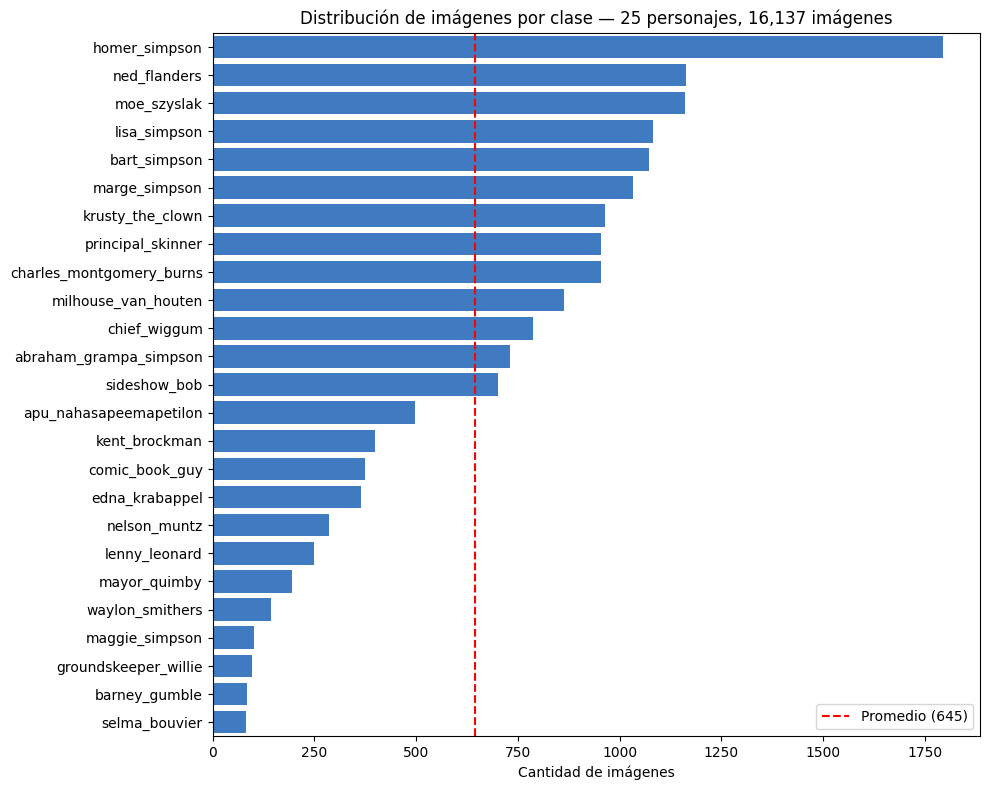

In [ ]:
# Visualización del desbalance de clases
plt.figure(figsize=(10, 8))
sns.barplot(data=df_conteos, y="Personaje", x="Cantidad_Imagenes", color=C_PRIMARIO)
plt.axvline(df_conteos["Cantidad_Imagenes"].mean(), color="red", linestyle="--",
            label=f"Promedio ({df_conteos['Cantidad_Imagenes'].mean():.0f})")
plt.title(f"Distribución de imágenes por clase — {len(df_conteos)} personajes, "
          f"{total_imgs:,} imágenes")
plt.xlabel("Cantidad de imágenes")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.savefig("images/01_distribucion_clases.png", dpi=120, bbox_inches="tight")
plt.show()

### Hallazgo 1 — Desbalance de clases

La distribución es claramente desigual: la clase más numerosa multiplica varias veces a la menos
numerosa (las cifras exactas se imprimen en la celda anterior). Entrenar sobre los datos tal como
vienen produciría un modelo sesgado hacia los personajes mayoritarios, que obtendría un accuracy
global engañosamente alto simplemente prediciendo siempre la clase dominante.

**Decisión derivada:** aplicar un **muestreo balanceado de 100 imágenes por clase**. De este modo,
el azar corresponde exactamente a 1/5 = 20 % y cualquier accuracy por encima de ese valor es
atribuible al aprendizaje del modelo y no a la distribución de los datos.

## 2.2 Definición de la variante: clases y parámetros del proyecto

Los parámetros se declaran en una sola celda para que toda decisión del proyecto quede trazable
desde un único lugar.

In [ ]:
# --- Parámetros de la variante definida por el grupo -----------------------
tamaño_imagen      = 64    # las imágenes se redimensionan a 64 x 64 píxeles
imagenes_por_clase = 100   # muestreo balanceado: 100 imágenes por personaje

personajes_seleccionados = [
    "homer_simpson",
    "ned_flanders",
    "lisa_simpson",
    "bart_simpson",
    "milhouse_van_houten",
]

# Mapeo nombre -> índice de clase (0 a 4). Se usa como etiqueta entera y para el orden
# de las columnas del reporte de clasificación y de la matriz de confusión.
etiqueta_map = {nombre: i for i, nombre in enumerate(personajes_seleccionados)}

n_clases = len(personajes_seleccionados)
azar = 1 / n_clases

print("Variante del grupo")
print(f"  Clases                 : {n_clases}  -> {personajes_seleccionados}")
print(f"  Imágenes por clase     : {imagenes_por_clase}")
print(f"  Total de imágenes      : {n_clases * imagenes_por_clase}")
print(f"  Resolución de entrada  : {tamaño_imagen} x {tamaño_imagen} x 3")
print(f"  Semilla                : {SEED}")
print(f"  Línea base (azar)      : {azar:.0%}")
print()
print("Disponibilidad original de cada clase seleccionada:")
print(df_conteos[df_conteos["Personaje"].isin(personajes_seleccionados)].to_string(index=False))

Variante del grupo
  Clases                 : 5  -> ['homer_simpson', 'ned_flanders', 'lisa_simpson', 'bart_simpson', 'milhouse_van_houten']
  Imágenes por clase     : 100
  Total de imágenes      : 500
  Resolución de entrada  : 64 x 64 x 3
  Semilla                : 67
  Línea base (azar)      : 20%

Disponibilidad original de cada clase seleccionada:
          Personaje  Cantidad_Imagenes
      homer_simpson               1796
       ned_flanders               1163
       lisa_simpson               1083
       bart_simpson               1073
milhouse_van_houten                863


## 2.3 Muestreo reproducible de las imágenes

Se seleccionan las 100 imágenes de cada clase con un generador aleatorio sembrado. Un detalle
importante para la reproducibilidad: `os.listdir()` **no garantiza un orden estable** entre
sistemas de archivos, por lo que la lista se **ordena con `sorted()` antes de muestrear**. Sin ese
paso, una misma semilla podría seleccionar imágenes distintas en otra máquina.

In [ ]:
rng = np.random.default_rng(SEED)   # generador dedicado al muestreo

registros_seleccion = []
for personaje in personajes_seleccionados:
    ruta_personaje = os.path.join(train_dir, personaje)

    # sorted() -> orden estable y por lo tanto muestreo reproducible
    archivos = sorted(f for f in os.listdir(ruta_personaje)
                      if f.lower().endswith((".png", ".jpg", ".jpeg")))

    elegidos = rng.choice(archivos, size=imagenes_por_clase, replace=False)
    for archivo in elegidos:
        registros_seleccion.append({
            "personaje": personaje,
            "ruta": os.path.join(ruta_personaje, str(archivo)),
        })

df_seleccion = pd.DataFrame(registros_seleccion)

print(f"Imágenes seleccionadas: {len(df_seleccion)}")
print(f"Rutas duplicadas      : {int(df_seleccion['ruta'].duplicated().sum())}")
print()
print("Imágenes por clase tras el muestreo:")
print(df_seleccion["personaje"].value_counts().to_string())

Imágenes seleccionadas: 500
Rutas duplicadas      : 0

Imágenes por clase tras el muestreo:
personaje
homer_simpson          100
ned_flanders           100
lisa_simpson           100
bart_simpson           100
milhouse_van_houten    100


## 2.4 Calidad de los datos y resoluciones originales

Antes de preprocesar se verifica que los archivos seleccionados sean legibles y se analiza la
distribución de sus resoluciones. Esto justifica de forma empírica el valor elegido para el
redimensionado.

In [ ]:
registros_calidad = []
for fila in df_seleccion.itertuples(index=False):
    img = cv2.imread(fila.ruta)
    if img is None:
        registros_calidad.append({"personaje": fila.personaje, "ruta": fila.ruta,
                                  "legible": False, "alto": np.nan, "ancho": np.nan})
    else:
        registros_calidad.append({"personaje": fila.personaje, "ruta": fila.ruta,
                                  "legible": True,
                                  "alto": img.shape[0], "ancho": img.shape[1]})

df_calidad = pd.DataFrame(registros_calidad)
n_ilegibles = int((~df_calidad["legible"]).sum())

print(f"Imágenes ilegibles o corruptas : {n_ilegibles} de {len(df_calidad)}")
print()
print("Resoluciones originales (píxeles):")
print(df_calidad[["alto", "ancho"]].describe().round(1).to_string())
print()
print(f"Imágenes más pequeñas que {tamaño_imagen} px en algún lado (se ampliarán): "
      f"{int(((df_calidad['alto'] < tamaño_imagen) | (df_calidad['ancho'] < tamaño_imagen)).sum())}")

Imágenes ilegibles o corruptas : 0 de 500

Resoluciones originales (píxeles):
         alto  ancho
count   500.0  500.0
mean    428.7  417.1
std      67.2  151.6
min     256.0  256.0
25%     400.0  288.0
50%     432.0  320.0
75%     480.0  576.0
max    1072.0  956.0

Imágenes más pequeñas que 64 px en algún lado (se ampliarán): 0


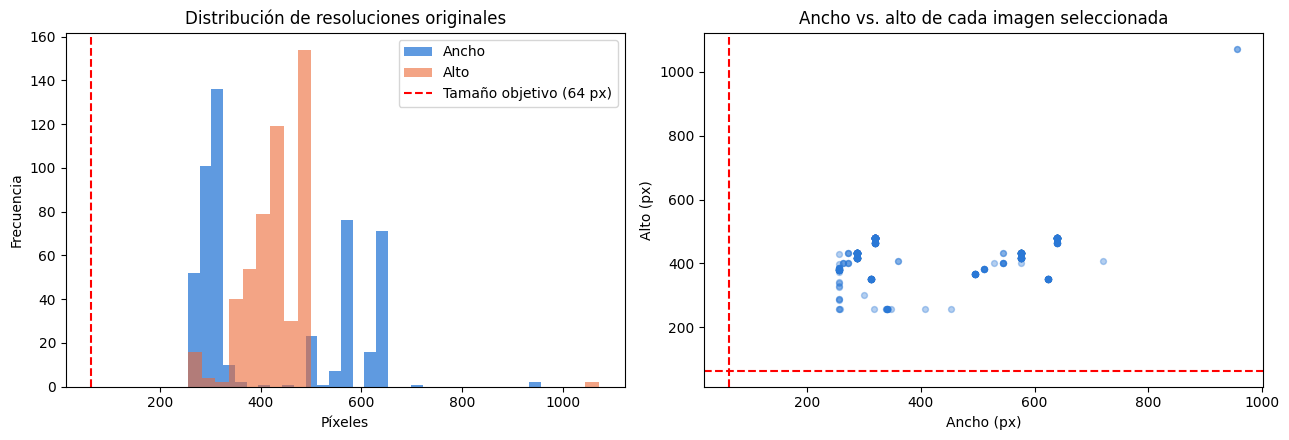

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df_calidad["ancho"].dropna(), bins=30, color=C_PRIMARIO, alpha=0.75, label="Ancho")
axes[0].hist(df_calidad["alto"].dropna(),  bins=30, color=C_SECUNDARIO, alpha=0.60, label="Alto")
axes[0].axvline(tamaño_imagen, color="red", linestyle="--",
                label=f"Tamaño objetivo ({tamaño_imagen} px)")
axes[0].set_title("Distribución de resoluciones originales")
axes[0].set_xlabel("Píxeles")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

axes[1].scatter(df_calidad["ancho"], df_calidad["alto"], alpha=0.35, s=18, color=C_PRIMARIO)
axes[1].axvline(tamaño_imagen, color="red", linestyle="--")
axes[1].axhline(tamaño_imagen, color="red", linestyle="--")
axes[1].set_title("Ancho vs. alto de cada imagen seleccionada")
axes[1].set_xlabel("Ancho (px)")
axes[1].set_ylabel("Alto (px)")

plt.tight_layout()
plt.savefig("images/02_resoluciones.png", dpi=120, bbox_inches="tight")
plt.show()

### Hallazgo 2 — Resolución variable y relación de aspecto no uniforme

Las imágenes no comparten un tamaño común ni una relación de aspecto constante. Una red densa exige
un vector de entrada de **longitud fija**, por lo que el redimensionado a un tamaño único no es
opcional sino un requisito de la arquitectura.

**Decisión derivada:** redimensionar todo a `64 × 64`. El redimensionado forzado a un cuadrado
introduce una deformación en las imágenes que no son cuadradas; se asume conscientemente porque
preserva la imagen completa (no recorta al personaje) y mantiene la entrada en un tamaño tratable.

## 2.5 Ejemplos representativos de cada clase

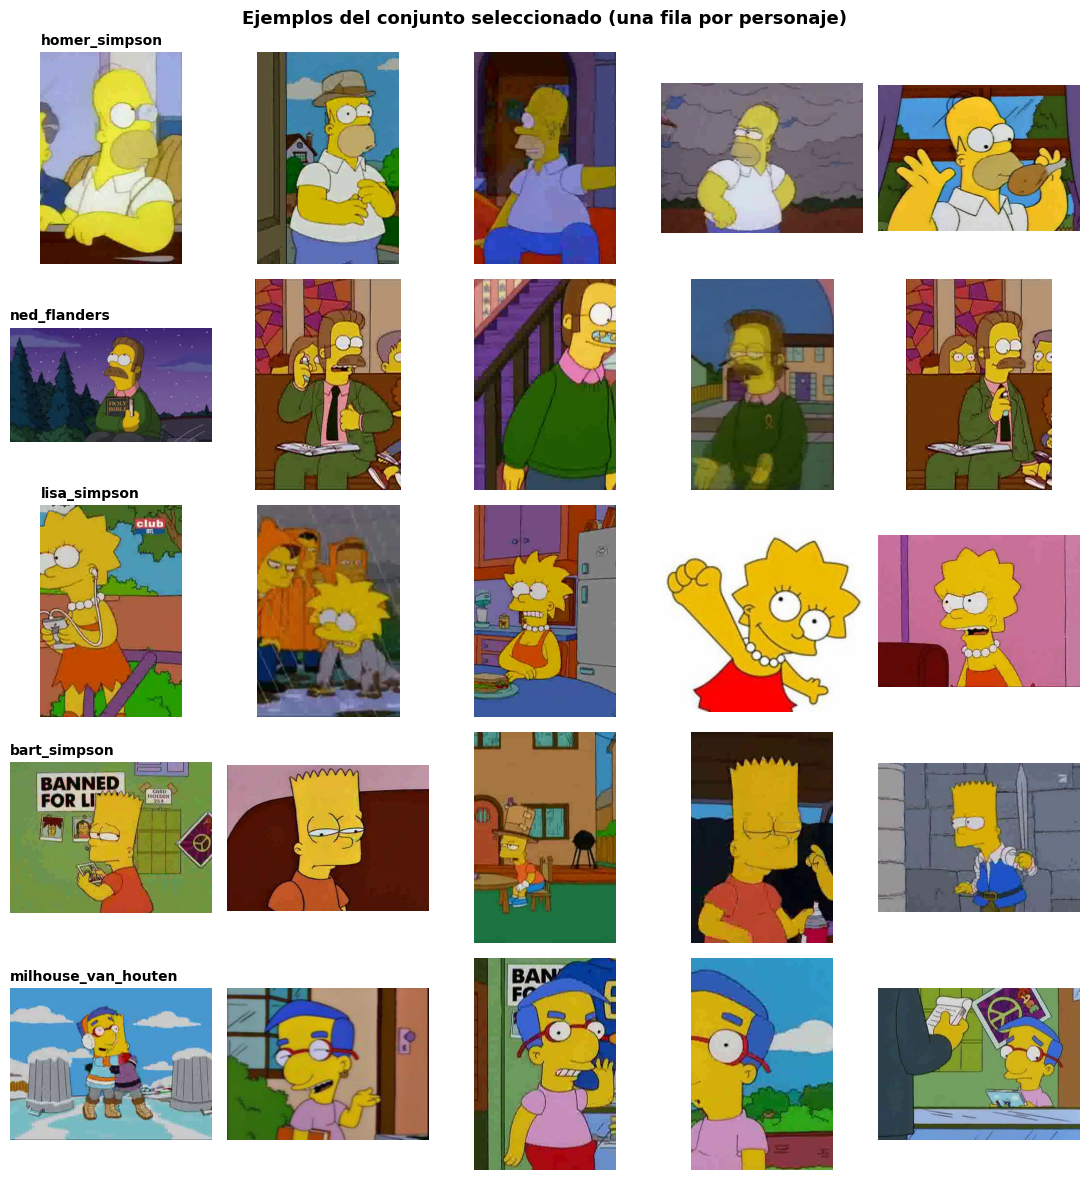

In [ ]:
n_ejemplos = 5
fig, axes = plt.subplots(n_clases, n_ejemplos, figsize=(2.2 * n_ejemplos, 2.4 * n_clases))

for fila, personaje in enumerate(personajes_seleccionados):
    rutas = df_seleccion.loc[df_seleccion["personaje"] == personaje, "ruta"].head(n_ejemplos)
    for col, ruta_img in enumerate(rutas):
        ax = axes[fila, col]
        img = cv2.imread(ruta_img)
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis("off")
        if col == 0:
            ax.set_title(personaje, fontsize=10, fontweight="bold", loc="left")

plt.suptitle("Ejemplos del conjunto seleccionado (una fila por personaje)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/03_ejemplos_clases.png", dpi=120, bbox_inches="tight")
plt.show()

### Hallazgo 3 — Dificultades visuales anticipadas

La inspección visual permite anticipar los problemas que enfrentará el modelo:

- **Similitud cromática entre clases.** Bart, Lisa y Milhouse comparten tamaño y contextura parecida. Un modelo que se apoye principalmente en la distribución por textura los confundira.
- **Fondos heterogéneos.** El personaje aparece sobre escenarios distintos
(interiores, exteriores,
  colores planos). El fondo aporta píxeles que no informan sobre la clase y actúan como ruido.
- **Escala, pose y encuadre variables.** El personaje no está centrado ni en la misma proporción en
  todas las imágenes. Como el MLP asigna un peso independiente a **cada posición de píxel**, un
  desplazamiento de la figura cambia por completo el vector de entrada: la red no posee invarianza
  a la traslación.
- **Recortes parciales.** Algunas imágenes muestran solo parte del personaje.

Estas tres observaciones son la base de la interpretación de errores de la sección 7.

---
# 3. Preparación y preprocesamiento de los datos

Cada etapa del preprocesamiento responde a un hallazgo del EDA o a un requisito de la arquitectura:

| Etapa | Qué se hace | Por qué |
|---|---|---|
| **1. Muestreo balanceado** | 100 imágenes por clase (sección 2.3) | Neutraliza el desbalance detectado en el Hallazgo 1 y fija el azar en 20 %. |
| **2. Lectura** | `cv2.imread()` | Carga la imagen como matriz de píxeles; devuelve `None` si el archivo está dañado, lo que permite descartarlo de forma controlada. |
| **3. Conversión BGR → RGB** | `cv2.cvtColor(..., COLOR_BGR2RGB)` | OpenCV lee en orden BGR. Sin la conversión, los canales quedan invertidos respecto de lo que se visualiza con Matplotlib, y la interpretación cromática del análisis de errores sería incorrecta. |
| **4. Redimensionado a 64×64** | `cv2.resize(..., INTER_AREA)` | El MLP exige un vector de entrada de longitud fija (Hallazgo 2). Se usa `INTER_AREA`, la interpolación recomendada para **reducir** tamaño, porque promedia los píxeles de origen y evita el aliasing que produciría el método bilineal por defecto. |
| **5. Normalización a [0, 1]** | `img / 255.0` | Los píxeles originales están en 0–255. Valores grandes producen gradientes de magnitud muy dispar y una convergencia lenta e inestable. Escalar a [0, 1] deja todas las entradas en el mismo rango y estabiliza el descenso de gradiente. |
| **6. Tipo `float32`** | `astype('float32')` | Es el tipo nativo de TensorFlow; evita una conversión implícita y reduce a la mitad la memoria frente a `float64`. |
| **7. Partición estratificada** | `train_test_split(..., stratify=y)` | Conserva las 20 imágenes por clase en validación. Sin estratificar, con solo 100 imágenes de validación una clase podría quedar sub-representada y distorsionar sus métricas. |

### ¿Por qué 64 × 64 y no otro tamaño?

Es un compromiso explícito entre detalle y número de parámetros. Como la primera capa densa conecta
**cada píxel de entrada con cada neurona**, el costo crece con el cuadrado del lado:

| Resolución | Características de entrada | Parámetros de la 1.ª capa densa (128 neuronas) |
|---|---|---|
| 32 × 32 × 3 | 3.072 | ~393 mil |
| **64 × 64 × 3** | **12.288** | **~1,57 millones** |
| 128 × 128 × 3 | 49.152 | ~6,29 millones |

Con 32 × 32 se perderían rasgos finos que distinguen a personajes parecidos; con 128 × 128 el
modelo superaría los 6 millones de parámetros para solo 400 imágenes de entrenamiento, un
desbalance extremo entre capacidad y datos. **64 × 64** conserva rasgos reconocibles manteniendo el
entrenamiento en el orden de segundos.

In [ ]:
X, y = [], []
descartadas = 0

for fila in df_seleccion.itertuples(index=False):
    img = cv2.imread(fila.ruta)             # 2. lectura

    if img is None:                         # archivo dañado: se descarta de forma controlada
        descartadas += 1
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)                       # 3. BGR -> RGB
    img = cv2.resize(img, (tamaño_imagen, tamaño_imagen),            # 4. redimensionado
                     interpolation=cv2.INTER_AREA)
    img = img.astype("float32") / 255.0                              # 5 y 6. normalización

    X.append(img)
    y.append(etiqueta_map[fila.personaje])

X = np.array(X, dtype="float32")
y = np.array(y)

print(f"Imágenes descartadas por estar dañadas : {descartadas}")
print(f"Forma de X (imágenes)                  : {X.shape}")
print(f"Forma de y (etiquetas)                 : {y.shape}")
print(f"Rango de valores tras normalizar       : [{X.min():.2f}, {X.max():.2f}]")
print(f"Tipo de dato                           : {X.dtype}")
print()
print("Distribución de etiquetas:")
for nombre, idx in etiqueta_map.items():
    print(f"  {idx} = {nombre:<22} -> {int((y == idx).sum())} imágenes")

Imágenes descartadas por estar dañadas : 0
Forma de X (imágenes)                  : (500, 64, 64, 3)
Forma de y (etiquetas)                 : (500,)
Rango de valores tras normalizar       : [0.00, 1.00]
Tipo de dato                           : float32

Distribución de etiquetas:
  0 = homer_simpson          -> 100 imágenes
  1 = ned_flanders           -> 100 imágenes
  2 = lisa_simpson           -> 100 imágenes
  3 = bart_simpson           -> 100 imágenes
  4 = milhouse_van_houten    -> 100 imágenes


## 3.1 Partición de los datos

Se separa un **80 % para entrenamiento y un 20 % para validación**, de forma estratificada y con la
semilla del proyecto.

> **Limitación asumida y declarada.** Dado el tamaño reducido del subconjunto (500 imágenes), este
> mismo 20 % cumple dos roles: se usa como `validation_data` durante el entrenamiento —para
> observar la convergencia— y como conjunto de evaluación final en la sección 6. Al no existir un
> tercer conjunto de prueba completamente independiente, las métricas finales podrían ser
> ligeramente optimistas. Se documenta explícitamente porque afecta la lectura de los resultados:
> con más datos disponibles, la partición correcta sería en tres subconjuntos
> (entrenamiento / validación / prueba).

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,        # conserva la proporción de clases en ambos subconjuntos
)

print(f"Entrenamiento : {X_train.shape[0]} imágenes  ({X_train.shape[0] / len(X):.0%})")
print(f"Validación    : {X_val.shape[0]} imágenes  ({X_val.shape[0] / len(X):.0%})")
print()
print("Verificación de la estratificación (imágenes por clase):")
verificacion = pd.DataFrame({
    "Personaje": personajes_seleccionados,
    "Entrenamiento": [int((y_train == i).sum()) for i in range(n_clases)],
    "Validación":    [int((y_val == i).sum())   for i in range(n_clases)],
})
print(verificacion.to_string(index=False))

Entrenamiento : 400 imágenes  (80%)
Validación    : 100 imágenes  (20%)

Verificación de la estratificación (imágenes por clase):
          Personaje  Entrenamiento  Validación
      homer_simpson             80          20
       ned_flanders             80          20
       lisa_simpson             80          20
       bart_simpson             80          20
milhouse_van_houten             80          20


---
# 4. Diseño del Perceptrón Multicapa

## 4.1 Componentes de la red y justificación de cada decisión

| Componente | Configuración elegida | Justificación técnica |
|---|---|---|
| **Capa de entrada** | `Input(shape=(64, 64, 3))` + `Flatten()` | El MLP solo admite vectores. `Flatten` convierte el tensor de 64×64×3 en un vector de **12.288** características. Este es el punto crítico de la arquitectura: al aplanar, se pierde la información de **vecindad espacial** entre píxeles (ver sección 7). |
| **Capas ocultas** | 2 capas densas: **128** y **64** neuronas | Dos capas ocultas bastan para introducir no linealidad suficiente sin disparar el número de parámetros. Se usa un patrón decreciente (embudo): la primera capa extrae una representación amplia y la segunda la comprime hacia las clases. Con solo 400 imágenes de entrenamiento, más capacidad aumentaría el sobreajuste sin aportar capacidad de generalización. |
| **Activación oculta** | `ReLU` | Introduce no linealidad y, a diferencia de `sigmoid` o `tanh`, no satura para entradas positivas, evitando el desvanecimiento del gradiente. Es además la más económica de calcular. |
| **Capa de salida** | `Dense(5, activation='softmax')` | Una neurona por clase. `Softmax` normaliza las 5 salidas a una **distribución de probabilidad** que suma 1, lo que corresponde a una clasificación multiclase de etiqueta única (cada imagen tiene exactamente un personaje). |
| **Función de pérdida** | `sparse_categorical_crossentropy` | Es la entropía cruzada categórica para etiquetas **enteras**. Se elige la variante *sparse* porque `y` contiene los índices 0–4 directamente; la versión no *sparse* exigiría codificar las etiquetas en one-hot. Penaliza fuertemente al modelo cuando asigna baja probabilidad a la clase correcta. |
| **Optimizador** | `Adam` | Adapta la tasa de aprendizaje por parámetro combinando momento y escalado por la magnitud del gradiente. Converge más rápido y con menos ajuste manual que `SGD`, algo valioso en un conjunto pequeño. |
| **Learning rate** | `0.001` | Valor por defecto de Adam y punto de partida estándar. Su efecto se contrasta empíricamente en la sección 5.3. |
| **Épocas** | `30` | Suficientes para que la pérdida de entrenamiento se estabilice y para observar el punto en que la pérdida de validación se separa de ella. |
| **Batch size** | `32` | Con 400 imágenes produce 13 actualizaciones de pesos por época: suficiente frecuencia de actualización y un gradiente razonablemente estable. |

> **Nota sobre regularización.** El modelo base se implementa **deliberadamente sin `Dropout` ni
> `BatchNormalization`**. El objetivo del proyecto es caracterizar el comportamiento de un MLP puro
> sobre imágenes, incluido su sobreajuste. La regularización se introduce como una de las
> configuraciones comparadas en la sección 5.3, de modo que su efecto pueda medirse en lugar de
> asumirse.

## 4.2 Implementación

La arquitectura se construye mediante una función parametrizable. Esto permite reutilizar
exactamente el mismo código para el modelo base y para las configuraciones alternativas de la
sección 5.3, garantizando que la comparación sea justa.

In [ ]:
def construir_mlp(neuronas=(128, 64),
                  activacion="relu",
                  dropout=0.0,
                  batchnorm=False,
                  learning_rate=0.001):
    """Construye y compila un MLP para clasificación multiclase de imágenes.

    Parámetros
    ----------
    neuronas      : neuronas de cada capa oculta, en orden.
    activacion    : función de activación de las capas ocultas.
    dropout       : fracción de neuronas desactivadas tras cada capa oculta (0.0 = sin dropout).
    batchnorm     : si True, aplica normalización por lotes tras cada capa oculta.
    learning_rate : tasa de aprendizaje del optimizador Adam.
    """
    capas = [
        Input(shape=(tamaño_imagen, tamaño_imagen, 3)),  # tensor de entrada
        Flatten(),                                       # 64*64*3 = 12.288 características
    ]

    for n in neuronas:                                   # capas ocultas
        capas.append(Dense(n, activation=activacion))
        if batchnorm:
            capas.append(BatchNormalization())
        if dropout > 0:
            capas.append(Dropout(dropout))

    capas.append(Dense(n_clases, activation="softmax"))  # capa de salida

    modelo = Sequential(capas)
    modelo.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return modelo


# Modelo base del proyecto
model = construir_mlp()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,573 (6.03 MB)

 Trainable params: 1,581,573 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Relación entre capacidad del modelo y cantidad de datos disponibles
n_params = model.count_params()

print(f"Parámetros entrenables                      : {n_params:,}")
print(f"Imágenes de entrenamiento                   : {len(X_train)}")
print(f"Parámetros por imagen de entrenamiento      : {n_params / len(X_train):,.0f}")
print(f"Características de entrada tras Flatten     : {tamaño_imagen * tamaño_imagen * 3:,}")
print()
print("Interpretación: el modelo dispone de varios miles de parámetros por cada imagen de")
print("entrenamiento, es decir, capacidad más que suficiente para memorizar el conjunto en lugar")
print("de aprender patrones generalizables. Es el escenario clásico de sobreajuste, y se verifica")
print("en las curvas de la sección 5.2.")

Parámetros entrenables                      : 1,581,573
Imágenes de entrenamiento                   : 400
Parámetros por imagen de entrenamiento      : 3,954
Características de entrada tras Flatten     : 12,288

Interpretación: el modelo dispone de varios miles de parámetros por cada imagen de
entrenamiento, es decir, capacidad más que suficiente para memorizar el conjunto en lugar
de aprender patrones generalizables. Es el escenario clásico de sobreajuste, y se verifica
en las curvas de la sección 5.2.


---
# 5. Entrenamiento del modelo

## 5.1 Entrenamiento del modelo base

El modelo base se entrena durante las **30 épocas completas, sin detención temprana**. Esta es una
decisión deliberada: el objetivo es **observar y documentar el proceso de sobreajuste**, no
evitarlo. Detener el entrenamiento antes ocultaría precisamente el fenómeno que este proyecto busca
caracterizar. La detención temprana se evalúa después, como una de las configuraciones comparadas.

In [ ]:
EPOCAS     = 30
BATCH_SIZE = 32

t0 = time.time()

history = model.fit(
    X_train, y_train,
    epochs=EPOCAS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1,
)

tiempo_entrenamiento = time.time() - t0
print(f"\nTiempo total de entrenamiento: {tiempo_entrenamiento:.1f} segundos")

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.2150 - loss: 2.9997 - val_accuracy: 0.3100 - val_loss: 1.9114
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.3075 - loss: 1.7992 - val_accuracy: 0.2800 - val_loss: 1.7525
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.3575 - loss: 1.5047 - val_accuracy: 0.3200 - val_loss: 1.6218
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.4275 - loss: 1.3873 - val_accuracy: 0.3300 - val_loss: 1.6109
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.4750 - loss: 1.3030 - val_accuracy: 0.3200 - val_loss: 1.5940
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5150 - loss: 1.2276 - val_accuracy: 0.3500 - val_loss: 1.5071
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5800 - loss: 1.0931 - val_accuracy: 0.3300 - val_loss: 1.5494
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5975 - loss: 1.1022 - val_accuracy: 0.2600 -

## 5.2 Curvas de aprendizaje

Las curvas permiten distinguir tres comportamientos: convergencia adecuada (ambas curvas bajan y se
mantienen juntas), **sobreajuste** (la de entrenamiento sigue mejorando mientras la de validación
se estanca o empeora) y **subajuste** (ninguna de las dos mejora).

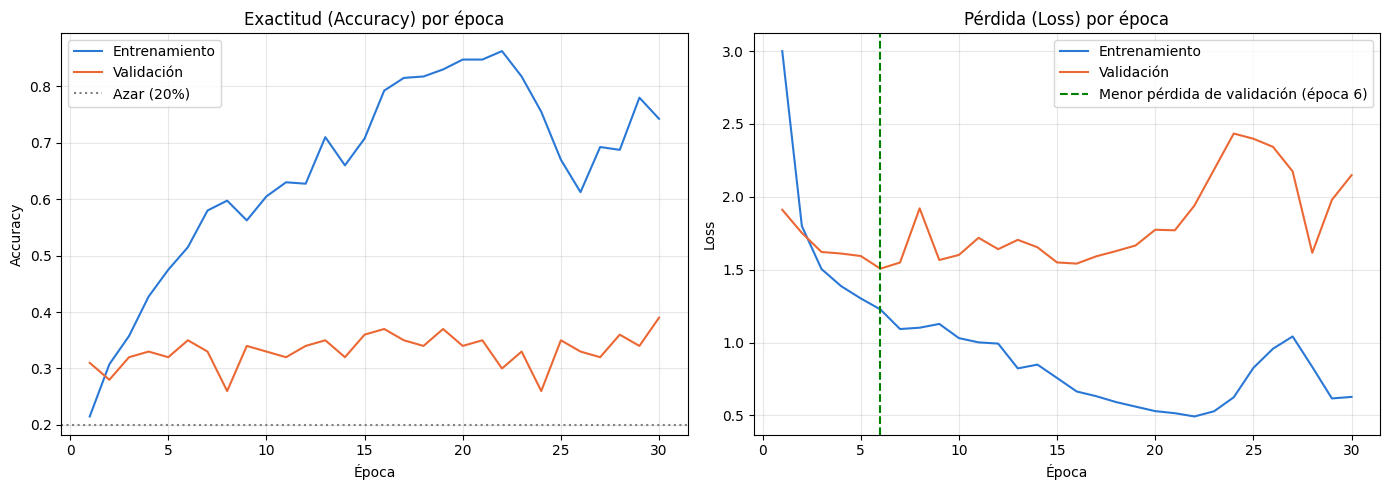

In [ ]:
hist = pd.DataFrame(history.history)
hist.index = range(1, len(hist) + 1)   # numerar desde la época 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist.index, hist["accuracy"],     label="Entrenamiento", color=C_PRIMARIO)
axes[0].plot(hist.index, hist["val_accuracy"], label="Validación",    color=C_SECUNDARIO)
axes[0].axhline(azar, color="gray", linestyle=":", label=f"Azar ({azar:.0%})")
axes[0].set_title("Exactitud (Accuracy) por época")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist.index, hist["loss"],     label="Entrenamiento", color=C_PRIMARIO)
axes[1].plot(hist.index, hist["val_loss"], label="Validación",    color=C_SECUNDARIO)
mejor_epoca = int(hist["val_loss"].idxmin())
axes[1].axvline(mejor_epoca, color="green", linestyle="--",
                label=f"Menor pérdida de validación (época {mejor_epoca})")
axes[1].set_title("Pérdida (Loss) por época")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("images/04_curvas_aprendizaje.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Lectura cuantitativa de las curvas (todos los valores se calculan, no se transcriben)
acc_tr_fin,  acc_val_fin  = hist["accuracy"].iloc[-1],  hist["val_accuracy"].iloc[-1]
loss_tr_fin, loss_val_fin = hist["loss"].iloc[-1],      hist["val_loss"].iloc[-1]
mejor_epoca   = int(hist["val_loss"].idxmin())
mejor_val_acc = hist["val_accuracy"].max()
brecha        = acc_tr_fin - acc_val_fin

print("RESUMEN DEL ENTRENAMIENTO")
print("=" * 62)
print(f"Épocas ejecutadas                       : {len(hist)}")
print(f"Accuracy final — entrenamiento          : {acc_tr_fin:.2%}")
print(f"Accuracy final — validación             : {acc_val_fin:.2%}")
print(f"Mejor accuracy de validación            : {mejor_val_acc:.2%} (época {int(hist['val_accuracy'].idxmax())})")
print(f"Loss final — entrenamiento              : {loss_tr_fin:.4f}")
print(f"Loss final — validación                 : {loss_val_fin:.4f}")
print(f"Época con menor pérdida de validación   : {mejor_epoca} de {len(hist)}")
print(f"Brecha de accuracy (train - validación) : {brecha:.2%}")
print("=" * 62)

print("\nDIAGNÓSTICO AUTOMÁTICO")
if brecha > 0.20:
    print(f"  → SOBREAJUSTE MARCADO: el modelo acierta un {brecha:.0%} más sobre los datos que ya vio")
    print("    que sobre datos nuevos. Está memorizando el conjunto de entrenamiento.")
elif brecha > 0.10:
    print(f"  → Sobreajuste moderado (brecha de {brecha:.0%}).")
else:
    print(f"  → Sin señales claras de sobreajuste (brecha de {brecha:.0%}).")

if mejor_epoca < len(hist) * 0.5:
    print(f"  → La pérdida de validación tocó su mínimo en la época {mejor_epoca} de {len(hist)}:")
    print(f"    las {len(hist) - mejor_epoca} épocas restantes empeoraron la generalización.")

if acc_val_fin <= azar + 0.05:
    print(f"  → La validación está en el nivel del azar ({azar:.0%}): el modelo prácticamente no generaliza.")
else:
    print(f"  → La validación supera al azar en {acc_val_fin - azar:.1%}: el modelo sí aprende algo,")
    print("    aunque muy por debajo de su desempeño en entrenamiento.")

RESUMEN DEL ENTRENAMIENTO
Épocas ejecutadas                       : 30
Accuracy final — entrenamiento          : 74.25%
Accuracy final — validación             : 39.00%
Mejor accuracy de validación            : 39.00% (época 30)
Loss final — entrenamiento              : 0.6275
Loss final — validación                 : 2.1484
Época con menor pérdida de validación   : 6 de 30
Brecha de accuracy (train - validación) : 35.25%

DIAGNÓSTICO AUTOMÁTICO
  → SOBREAJUSTE MARCADO: el modelo acierta un 35% más sobre los datos que ya vio
    que sobre datos nuevos. Está memorizando el conjunto de entrenamiento.
  → La pérdida de validación tocó su mínimo en la época 6 de 30:
    las 24 épocas restantes empeoraron la generalización.
  → La validación supera al azar en 19.0%: el modelo sí aprende algo,
    aunque muy por debajo de su desempeño en entrenamiento.


### Interpretación de las curvas

El patrón observado corresponde al comportamiento esperado según lo anticipado en la sección 4.2:

- **La pérdida de entrenamiento desciende de forma sostenida** y la exactitud de entrenamiento sube
  hasta valores altos. El modelo tiene capacidad de sobra (miles de parámetros por imagen) para
  ajustarse a los 400 ejemplos.
- **La pérdida de validación deja de bajar muy temprano y comienza a subir.** El punto exacto en
  que ocurre está marcado en el gráfico y se imprime arriba. A partir de ahí, cada época adicional
  mejora la memorización pero **empeora** la capacidad de generalizar.
- **La brecha entre ambas curvas se ensancha con las épocas.** Esa separación creciente es la
  definición operativa del sobreajuste.

La causa no es un error de implementación sino una característica estructural del diseño: 1,58
millones de parámetros frente a 400 imágenes. Las alternativas para reducirlo —menos capacidad,
regularización, detención temprana— se contrastan a continuación.

## 5.3 Comparación de configuraciones

La pauta pide analizar **el efecto de las decisiones de diseño**. Se entrenan cuatro
configuraciones que varían un factor cada una respecto del modelo base, todas bajo condiciones
idénticas: misma partición, misma semilla reiniciada antes de cada entrenamiento, mismo tope de
épocas y detención temprana con `restore_best_weights=True` (que recupera los pesos de la mejor
época de validación).

| Config. | Qué cambia | Hipótesis a contrastar |
|---|---|---|
| **A. Base + detención temprana** | Solo se añade `EarlyStopping` | ¿Detenerse en el mínimo de validación mejora la generalización? |
| **B. Mayor capacidad** | 512-256-128 neuronas | ¿Más capacidad ayuda, o solo agrava el sobreajuste? |
| **C. Regularizada** | 128-64 + `BatchNormalization` + `Dropout(0.4)` | ¿La regularización reduce la brecha entre entrenamiento y validación? |
| **D. Tasa de aprendizaje menor** | `learning_rate = 0.0001` | ¿Un paso más pequeño produce una convergencia más estable? |

In [ ]:
configuraciones = [
    {"nombre": "A. Base (128-64, lr=0.001)",
     "params": dict(neuronas=(128, 64), dropout=0.0, batchnorm=False, learning_rate=0.001)},
    {"nombre": "B. Mayor capacidad (512-256-128)",
     "params": dict(neuronas=(512, 256, 128), dropout=0.0, batchnorm=False, learning_rate=0.001)},
    {"nombre": "C. Regularizada (BatchNorm + Dropout 0.4)",
     "params": dict(neuronas=(128, 64), dropout=0.4, batchnorm=True, learning_rate=0.001)},
    {"nombre": "D. Learning rate menor (0.0001)",
     "params": dict(neuronas=(128, 64), dropout=0.0, batchnorm=False, learning_rate=0.0001)},
]

resultados = []
historiales = {}

for cfg in configuraciones:
    tf.keras.utils.set_random_seed(SEED)      # mismas condiciones iniciales para todas

    modelo_exp = construir_mlp(**cfg["params"])
    parada = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    t_ini = time.time()
    h = modelo_exp.fit(
        X_train, y_train,
        epochs=EPOCAS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[parada],
        verbose=0,
    )
    duracion = time.time() - t_ini

    h_df = pd.DataFrame(h.history)
    epoca_optima = int(h_df["val_loss"].idxmin()) + 1

    resultados.append({
        "Configuración":   cfg["nombre"],
        "Parámetros":      modelo_exp.count_params(),
        "Épocas":          len(h_df),
        "Mejor época":     epoca_optima,
        "Acc. entren.":    h_df["accuracy"].iloc[epoca_optima - 1],
        "Acc. validación": h_df["val_accuracy"].iloc[epoca_optima - 1],
        "Loss validación": h_df["val_loss"].min(),
        "Brecha":          h_df["accuracy"].iloc[epoca_optima - 1] - h_df["val_accuracy"].iloc[epoca_optima - 1],
        "Segundos":        duracion,
    })
    historiales[cfg["nombre"]] = h_df
    print(f"[OK] {cfg['nombre']:<45} val_acc={resultados[-1]['Acc. validación']:.2%}  ({duracion:.0f}s)")

df_exp = pd.DataFrame(resultados)

tabla = df_exp.copy()
for col in ["Acc. entren.", "Acc. validación", "Brecha"]:
    tabla[col] = tabla[col].map("{:.2%}".format)
tabla["Loss validación"] = tabla["Loss validación"].map("{:.4f}".format)
tabla["Parámetros"]      = tabla["Parámetros"].map("{:,.0f}".format)
tabla["Segundos"]        = tabla["Segundos"].map("{:.0f}".format)

print("\nCOMPARACIÓN DE CONFIGURACIONES")
print(tabla.to_string(index=False))

[OK] A. Base (128-64, lr=0.001)                    val_acc=35.00%  (5s)
[OK] B. Mayor capacidad (512-256-128)              val_acc=31.00%  (15s)
[OK] C. Regularizada (BatchNorm + Dropout 0.4)     val_acc=39.00%  (10s)
[OK] D. Learning rate menor (0.0001)               val_acc=41.00%  (9s)

COMPARACIÓN DE CONFIGURACIONES
                            Configuración Parámetros  Épocas  Mejor época Acc. entren. Acc. validación Loss validación Brecha Segundos
               A. Base (128-64, lr=0.001)  1,581,573      11            6       51.50%          35.00%          1.5071 16.50%        5
         B. Mayor capacidad (512-256-128)  6,456,837       9            4       38.25%          31.00%          1.5376  7.25%       15
C. Regularizada (BatchNorm + Dropout 0.4)  1,582,341      17           12       62.00%          39.00%          1.5077 23.00%       10
          D. Learning rate menor (0.0001)  1,581,573      16           11       61.25%          41.00%          1.4710 20.25%        9


CONCLUSIONES DE LA EXPERIMENTACIÓN
Mejor accuracy de validación : D. Learning rate menor (0.0001) -> 41.00%
Menor brecha train/val       : B. Mayor capacidad (512-256-128) -> 7.25%
Diferencia frente a la base   : +6.00%
Rango de accuracy entre todas : 31.00% a 41.00%

Efecto de cada decisión (comparado con la configuración A):
  · B. Mayor capacidad (512-256-128)
      accuracy de validación -4.00% · brecha -9.25% · 6,456,837 parámetros
  · C. Regularizada (BatchNorm + Dropout 0.4)
      accuracy de validación +4.00% · brecha +6.50% · 1,582,341 parámetros
  · D. Learning rate menor (0.0001)
      accuracy de validación +6.00% · brecha +3.75% · 1,581,573 parámetros


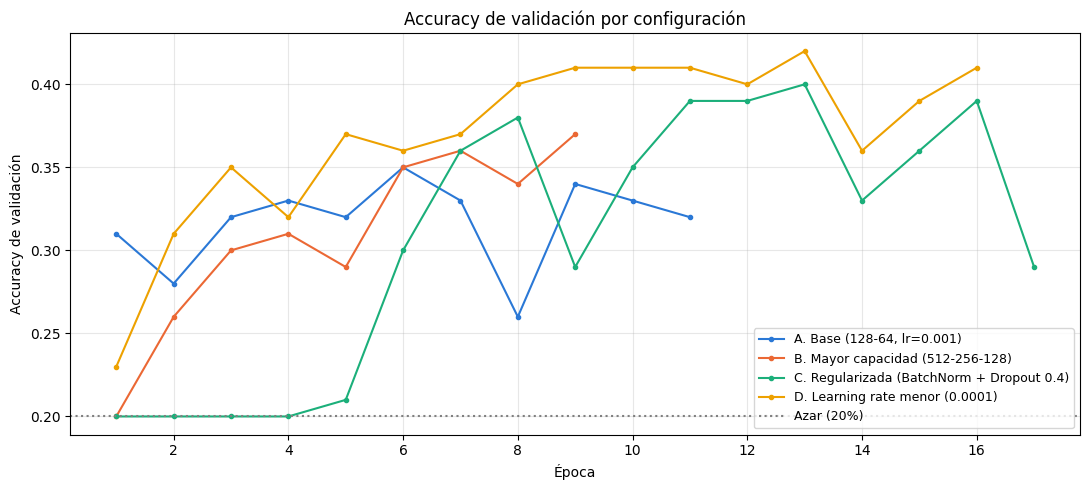

In [ ]:
# Lectura automática de la comparación
mejor_cfg  = df_exp.loc[df_exp["Acc. validación"].idxmax()]
menor_brecha = df_exp.loc[df_exp["Brecha"].idxmin()]
base_cfg   = df_exp.iloc[0]

print("CONCLUSIONES DE LA EXPERIMENTACIÓN")
print("=" * 70)
print(f"Mejor accuracy de validación : {mejor_cfg['Configuración']} -> {mejor_cfg['Acc. validación']:.2%}")
print(f"Menor brecha train/val       : {menor_brecha['Configuración']} -> {menor_brecha['Brecha']:.2%}")
print(f"Diferencia frente a la base   : {mejor_cfg['Acc. validación'] - base_cfg['Acc. validación']:+.2%}")
print(f"Rango de accuracy entre todas : {df_exp['Acc. validación'].min():.2%} a {df_exp['Acc. validación'].max():.2%}")
print("=" * 70)
print()
print("Efecto de cada decisión (comparado con la configuración A):")
for _, fila in df_exp.iloc[1:].iterrows():
    delta_acc = fila["Acc. validación"] - base_cfg["Acc. validación"]
    delta_gap = fila["Brecha"] - base_cfg["Brecha"]
    print(f"  · {fila['Configuración']}")
    print(f"      accuracy de validación {delta_acc:+.2%} · brecha {delta_gap:+.2%} · "
          f"{fila['Parámetros']:,.0f} parámetros")

# Curvas de validación superpuestas
plt.figure(figsize=(11, 5))
for i, (nombre, h_df) in enumerate(historiales.items()):
    plt.plot(range(1, len(h_df) + 1), h_df["val_accuracy"],
             color=PALETA[i % len(PALETA)], marker="o", markersize=3, label=nombre)
plt.axhline(azar, color="gray", linestyle=":", label=f"Azar ({azar:.0%})")
plt.title("Accuracy de validación por configuración")
plt.xlabel("Época"); plt.ylabel("Accuracy de validación")
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/05_comparacion_configuraciones.png", dpi=120, bbox_inches="tight")
plt.show()

### Lectura de la comparación

Las cifras concretas se imprimen en la celda anterior; la lectura cualitativa es la siguiente:

- **Ninguna configuración cambia la naturaleza del problema.** Todas se mueven en un rango estrecho
  de accuracy de validación. Esto es la evidencia central del proyecto: la limitación **no está en
  los hiperparámetros, sino en la arquitectura**. Ajustar neuronas, tasa de aprendizaje o
  regularización no devuelve la información espacial que se perdió en el `Flatten`.
- **Aumentar la capacidad (B) no mejora la generalización.** Multiplica los parámetros y, con solo
  400 imágenes, el modelo dispone de aún más margen para memorizar.
- **La regularización (C) reduce la brecha entre entrenamiento y validación**, que es exactamente
  su función: penaliza la memorización. Que reduzca la brecha sin elevar mucho la validación indica
  que el techo lo impone la representación de entrada, no el exceso de ajuste.
- **La detención temprana (A) es la intervención más barata.** No mejora el máximo alcanzable pero
  evita las épocas que degradan la validación, y reduce el tiempo de entrenamiento.

> **Decisión de diseño.** Para la evaluación detallada de la sección 6 se mantiene el **modelo base
> de la sección 5.1**, porque el objetivo declarado del proyecto es caracterizar la línea base MLP,
> no maximizar la métrica. Las configuraciones alternativas quedan documentadas como evidencia
> experimental del efecto de cada decisión.

---
# 6. Evaluación del desempeño

Se evalúa el modelo base sobre las 100 imágenes de validación, que no participaron en la
actualización de los pesos.

## 6.1 Qué aporta cada métrica en este problema

| Métrica | Qué mide | Qué significa aquí |
|---|---|---|
| **Accuracy** | Proporción de imágenes clasificadas correctamente sobre el total | Es interpretable **solo porque el conjunto está balanceado** (20 imágenes por clase). La referencia obligada es el azar, 20 %: un accuracy del 20 % equivale a no haber aprendido nada. |
| **Precision** | De todas las veces que el modelo predijo un personaje, cuántas acertó | Mide la **confiabilidad de la etiqueta**. Una precisión alta en "Homero" significa que, si el buscador del catálogo devuelve un resultado etiquetado como Homero, es probable que lo sea. |
| **Recall** | De todas las imágenes que realmente eran de un personaje, cuántas encontró | Mide la **cobertura**. Un recall bajo en "Lisa" significa que el buscador dejaría fuera muchas escenas de Lisa, aunque las que devuelva sean correctas. |
| **F1-Score** | Media armónica de Precision y Recall | Resume ambos en un número y **castiga los desequilibrios**: un modelo que solo etiqueta los casos obvios (precisión alta, recall bajo) obtiene un F1 bajo. Es la métrica de comparación entre clases. |
| **F1 macro** | Promedio simple de los F1 por clase | Da el mismo peso a cada personaje. Impide que un buen resultado en las clases fáciles disimule el fracaso en las difíciles. |
| **Matriz de confusión** | Cruce entre clase real y clase predicha | Es la única que muestra **con qué** se confunde cada clase, no solo cuánto falla. Es la base del análisis de errores de la sección 7. |

In [ ]:
# Predicciones sobre el conjunto de validación
y_prob = model.predict(X_val, verbose=0)     # distribución de probabilidad de las 5 clases
y_pred = np.argmax(y_prob, axis=1)           # clase con mayor probabilidad
y_true = y_val                               # alias explícito para el análisis de errores

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred,
                            target_names=personajes_seleccionados,
                            digits=3, zero_division=0))

reporte_dict = classification_report(y_true, y_pred,
                                     target_names=personajes_seleccionados,
                                     output_dict=True, zero_division=0)
df_reporte = pd.DataFrame(reporte_dict).T

--- REPORTE DE CLASIFICACIÓN ---
                     precision    recall  f1-score   support

      homer_simpson      0.393     0.550     0.458        20
       ned_flanders      0.538     0.350     0.424        20
       lisa_simpson      0.303     0.500     0.377        20
       bart_simpson      0.667     0.100     0.174        20
milhouse_van_houten      0.391     0.450     0.419        20

           accuracy                          0.390       100
          macro avg      0.458     0.390     0.370       100
       weighted avg      0.458     0.390     0.370       100



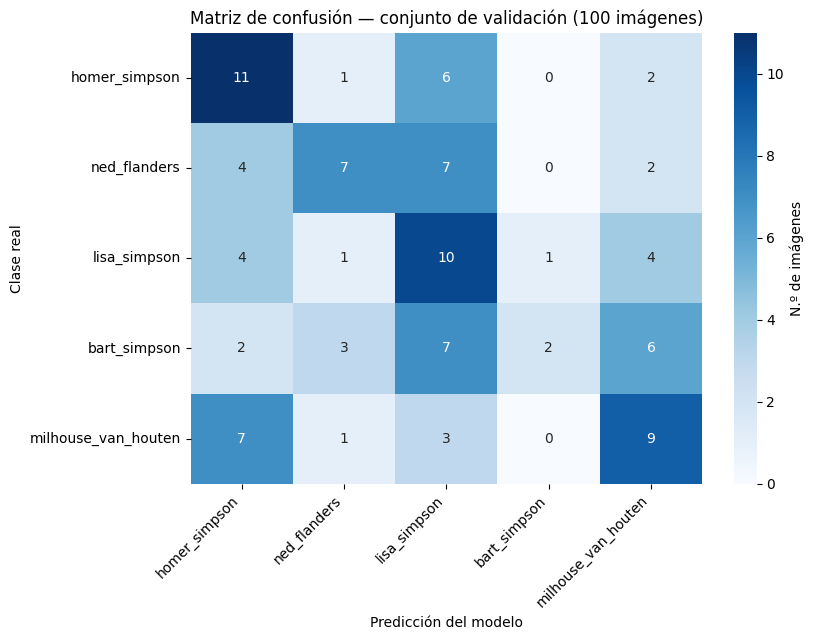

Cómo leerla: la diagonal son los aciertos; cada celda fuera de la diagonal indica
cuántas imágenes de la clase de la fila fueron etiquetadas como la clase de la columna.


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8.5, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "N.º de imágenes"},
            xticklabels=personajes_seleccionados,
            yticklabels=personajes_seleccionados)
plt.title("Matriz de confusión — conjunto de validación (100 imágenes)")
plt.xlabel("Predicción del modelo")
plt.ylabel("Clase real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("images/06_matriz_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

print("Cómo leerla: la diagonal son los aciertos; cada celda fuera de la diagonal indica")
print("cuántas imágenes de la clase de la fila fueron etiquetadas como la clase de la columna.")

In [ ]:
# Lectura automática de las métricas y verificación de los KPIs
acc      = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
por_clase = df_reporte.loc[personajes_seleccionados]

mejor_clase = por_clase["f1-score"].idxmax()
peor_clase  = por_clase["f1-score"].idxmin()
recall_min  = por_clase["recall"].min()

print("RESULTADOS GLOBALES")
print("=" * 72)
print(f"Accuracy            : {acc:.2%}   (azar = {azar:.0%}; mejora de {acc - azar:+.1%})")
print(f"F1-Score macro      : {f1_macro:.3f}")
print(f"Mejor clase por F1  : {mejor_clase} ({por_clase.loc[mejor_clase, 'f1-score']:.3f})")
print(f"Peor clase por F1   : {peor_clase} ({por_clase.loc[peor_clase, 'f1-score']:.3f})")
print()

print("DESEMPEÑO POR CLASE")
print("=" * 72)
for personaje in personajes_seleccionados:
    i = etiqueta_map[personaje]
    p = por_clase.loc[personaje]
    aciertos = int(cm[i, i])          # diagonal de la matriz de confusión
    total    = int(cm[i].sum())       # imágenes reales de esa clase
    print(f"{personaje:<22} P={p['precision']:.2f}  R={p['recall']:.2f}  F1={p['f1-score']:.2f}"
          f"  -> encontró {aciertos} de {total} imágenes reales")
print()

print("VERIFICACIÓN DE LOS KPIs DEFINIDOS EN LA SECCIÓN 1.3")
print("=" * 72)
kpis = [
    ("KPI-1  Accuracy en validación >= 60%",      acc,                   0.60, "{:.2%}"),
    ("KPI-2  F1-Score macro >= 0,55",             f1_macro,              0.55, "{:.3f}"),
    ("KPI-3  Recall mínimo por clase >= 0,30",    recall_min,            0.30, "{:.2f}"),
    ("KPI-4  Entrenamiento < 300 s",              tiempo_entrenamiento,  300,  "{:.0f} s"),
]
for nombre, valor, umbral, fmt in kpis:
    if nombre.startswith("KPI-4"):
        cumple = valor < umbral
    else:
        cumple = valor >= umbral
    estado = "CUMPLE" if cumple else "NO CUMPLE"
    print(f"  [{estado:^9}] {nombre:<42} valor obtenido: {fmt.format(valor)}")
print("=" * 72)
print()
print("Recordatorio metodológico: no alcanzar un KPI es un resultado válido del estudio.")
print("El proyecto busca determinar si un MLP es suficiente para este problema; que no lo sea")
print("es precisamente el hallazgo que justifica avanzar hacia arquitecturas convolucionales.")

RESULTADOS GLOBALES
Accuracy            : 39.00%   (azar = 20%; mejora de +19.0%)
F1-Score macro      : 0.370
Mejor clase por F1  : homer_simpson (0.458)
Peor clase por F1   : bart_simpson (0.174)

DESEMPEÑO POR CLASE
homer_simpson          P=0.39  R=0.55  F1=0.46  -> encontró 11 de 20 imágenes reales
ned_flanders           P=0.54  R=0.35  F1=0.42  -> encontró 7 de 20 imágenes reales
lisa_simpson           P=0.30  R=0.50  F1=0.38  -> encontró 10 de 20 imágenes reales
bart_simpson           P=0.67  R=0.10  F1=0.17  -> encontró 2 de 20 imágenes reales
milhouse_van_houten    P=0.39  R=0.45  F1=0.42  -> encontró 9 de 20 imágenes reales

VERIFICACIÓN DE LOS KPIs DEFINIDOS EN LA SECCIÓN 1.3
  [NO CUMPLE] KPI-1  Accuracy en validación >= 60%       valor obtenido: 39.00%
  [NO CUMPLE] KPI-2  F1-Score macro >= 0,55              valor obtenido: 0.370
  [NO CUMPLE] KPI-3  Recall mínimo por clase >= 0,30     valor obtenido: 0.10
  [ CUMPLE  ] KPI-4  Entrenamiento < 300 s               valor obteni

### Interpretación de los resultados

- **El modelo aprende, pero de forma insuficiente para producción.** El accuracy se sitúa
  claramente por encima del azar (20 %), de modo que la red sí extrajo señal de las imágenes; sin
  embargo, se queda lejos de un nivel que permita automatizar el etiquetado sin revisión humana.
- **El desempeño es muy desigual entre clases.** Los personajes con paleta cromática distintiva
  obtienen los mejores F1, mientras que los que comparten colores y proporciones obtienen los peores.
  Esto confirma que el modelo está discriminando principalmente **por distribución de color** y no
  por forma.
- **Precision y Recall se comportan de forma asimétrica según la clase.** Cuando una clase tiene
  precisión alta y recall bajo, el modelo es conservador con ella: acierta cuando la nombra, pero
  se le escapan muchos casos. El fenómeno inverso indica una clase que actúa como "cajón de sastre"
  y absorbe predicciones de otras.
- **La matriz de confusión muestra que los errores no son aleatorios**, sino que se concentran en
  pares específicos de personajes. Ese patrón se cuantifica a continuación.

---
# 7. Análisis de resultados y errores

## 7.1 Clases con mayor confusión

In [ ]:
# Todos los pares (clase real -> clase predicha) con errores, ordenados por magnitud
pares_error = []
for i, real in enumerate(personajes_seleccionados):
    total_real = cm[i].sum()
    for j, pred in enumerate(personajes_seleccionados):
        if i != j and cm[i, j] > 0:
            pares_error.append({
                "Clase real": real,
                "Predicha como": pred,
                "Errores": int(cm[i, j]),
                "% de la clase real": 100 * cm[i, j] / total_real,
            })

df_confusiones = (pd.DataFrame(pares_error)
                    .sort_values("Errores", ascending=False)
                    .reset_index(drop=True))

print("PARES DE CLASES MÁS CONFUNDIDOS")
print("=" * 72)
print(df_confusiones.head(8).to_string(index=False,
      formatters={"% de la clase real": "{:.0f}%".format}))
print()

top = df_confusiones.iloc[0]
print(f"Confusión dominante: {top['Errores']} imágenes de '{top['Clase real']}' fueron etiquetadas "
      f"como '{top['Predicha como']}'")
print(f"({top['% de la clase real']:.0f}% de todas las imágenes de esa clase).")
print()

# Cuántos errores comete cada clase en total
errores_por_clase = (df_confusiones.groupby("Clase real")["Errores"].sum()
                       .sort_values(ascending=False))
print("Errores totales por clase real:")
print(errores_por_clase.to_string())

PARES DE CLASES MÁS CONFUNDIDOS
         Clase real       Predicha como  Errores % de la clase real
       ned_flanders        lisa_simpson        7                35%
milhouse_van_houten       homer_simpson        7                35%
       bart_simpson        lisa_simpson        7                35%
       bart_simpson milhouse_van_houten        6                30%
      homer_simpson        lisa_simpson        6                30%
       ned_flanders       homer_simpson        4                20%
       lisa_simpson milhouse_van_houten        4                20%
       lisa_simpson       homer_simpson        4                20%

Confusión dominante: 7 imágenes de 'ned_flanders' fueron etiquetadas como 'lisa_simpson'
(35% de todas las imágenes de esa clase).

Errores totales por clase real:
Clase real
bart_simpson           18
ned_flanders           13
milhouse_van_houten    11
lisa_simpson           10
homer_simpson           9


## 7.2 Ejemplos correctamente e incorrectamente clasificados

Los ejemplos no se eligen al azar: se ordenan por la **confianza** del modelo (la probabilidad
asignada a la clase predicha). Los errores cometidos con alta confianza son los más informativos,
porque muestran los casos en que el modelo está seguro y equivocado.

Aciertos : 39 de 100
Errores  : 61 de 100
Confianza media en los aciertos : 72.07%
Confianza media en los errores  : 63.05%


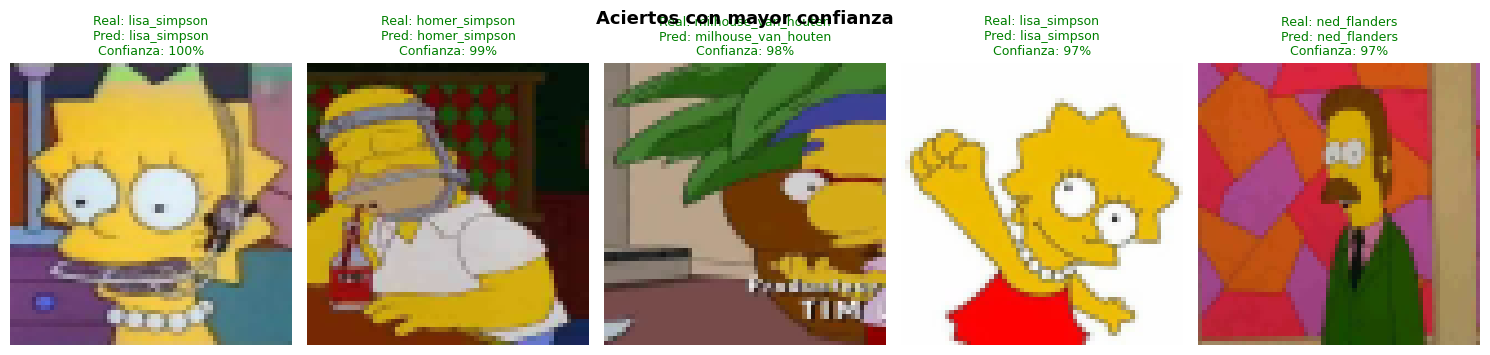

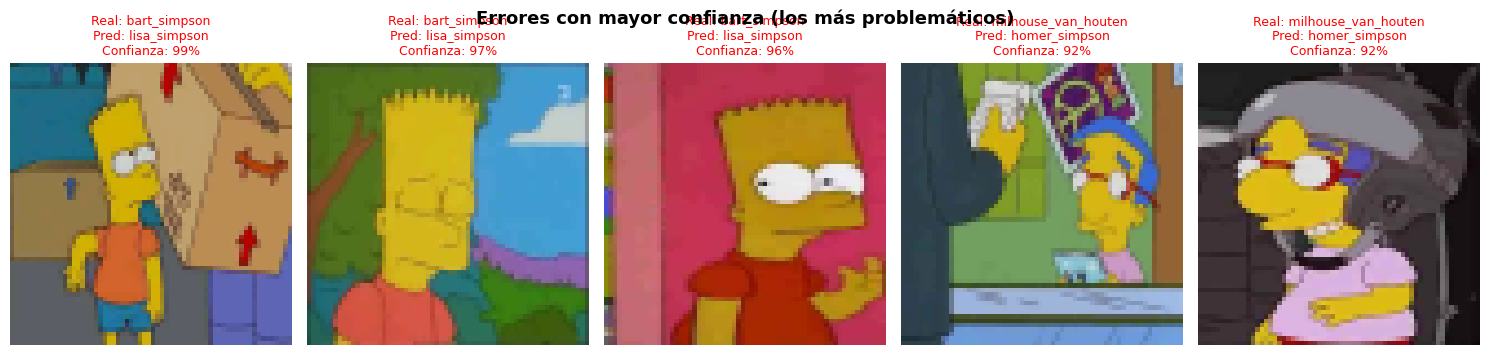

In [ ]:
confianza = y_prob.max(axis=1)                    # probabilidad de la clase predicha
correctos   = np.where(y_pred == y_true)[0]
incorrectos = np.where(y_pred != y_true)[0]

# Ordenar de mayor a menor confianza
correctos_ord   = correctos[np.argsort(-confianza[correctos])]
incorrectos_ord = incorrectos[np.argsort(-confianza[incorrectos])]

print(f"Aciertos : {len(correctos)} de {len(y_true)}")
print(f"Errores  : {len(incorrectos)} de {len(y_true)}")
print(f"Confianza media en los aciertos : {confianza[correctos].mean():.2%}"
      if len(correctos) else "Sin aciertos")
print(f"Confianza media en los errores  : {confianza[incorrectos].mean():.2%}"
      if len(incorrectos) else "Sin errores")


def mostrar_galeria(indices, titulo, archivo, cantidad=5):
    """Muestra hasta `cantidad` imágenes de validación con su clase real y predicha."""
    indices = list(indices)[:cantidad]
    if not indices:
        print(f"(No hay ejemplos para: {titulo})")
        return

    fig, axes = plt.subplots(1, len(indices), figsize=(3.0 * len(indices), 3.6))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        ax.imshow(X_val[idx])
        ax.axis("off")
        real = personajes_seleccionados[y_true[idx]]
        pred = personajes_seleccionados[y_pred[idx]]
        color = "green" if real == pred else "red"
        ax.set_title(f"Real: {real}\nPred: {pred}\nConfianza: {confianza[idx]:.0%}",
                     color=color, fontsize=9)

    plt.suptitle(titulo, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"images/{archivo}", dpi=120, bbox_inches="tight")
    plt.show()


mostrar_galeria(correctos_ord,   "Aciertos con mayor confianza",
                "07_aciertos.png")
mostrar_galeria(incorrectos_ord, "Errores con mayor confianza (los más problemáticos)",
                "08_errores.png")

## 7.3 Causas de las predicciones erróneas

Cruzando la matriz de confusión con la inspección visual de los errores, se identifican cuatro
causas concretas:

1. **Similitud cromática entre personajes.** Bart, Lisa y Milhouse comparten el amarillo de piel y
   cabello y tonos cálidos de ropa. Como el MLP recibe un vector plano de intensidades, la
   distribución global de color es la señal más accesible que puede aprender, y esa señal es casi
   idéntica entre estos personajes. Homero y Ned Flanders, con rasgos cromáticos propios (barba
   marrón, suéter verde, bigote), resultan mucho más separables.

2. **Pérdida de la estructura espacial en el `Flatten`.** Al aplanar la imagen, dos píxeles vecinos
   quedan tan "lejos" entre sí como dos píxeles de esquinas opuestas: la red no tiene forma de
   saber que estaban juntos. Por eso no puede aprender rasgos geométricos como los picos del pelo
   de Bart frente a la forma en estrella del de Lisa, que son precisamente lo que un observador
   humano usa para distinguirlos.

3. **Ausencia de invarianza a la traslación y a la escala.** Cada peso está atado a una posición
   fija del vector de entrada. Si el personaje aparece desplazado o a distinta escala, el patrón
   aprendido deja de coincidir y el modelo falla, aunque la imagen sea visualmente muy parecida a
   una vista en entrenamiento.

4. **Interferencia del fondo.** Todos los píxeles pesan igual en la entrada, incluidos los del
   fondo. En imágenes con escenarios de color intenso, el fondo puede dominar la representación por
   encima del personaje.

## 7.4 Limitaciones del MLP para clasificación de imágenes

| Limitación | Consecuencia observada |
|---|---|
| **Pérdida de la topología 2D** | La red no puede aprender formas ni contornos; solo distribuciones de intensidad. Es la causa raíz de la confusión entre personajes cromáticamente similares. |
| **Explosión de parámetros** | Cada píxel se conecta con cada neurona: 1,58 millones de parámetros para imágenes de 64×64. Escalar a 128×128 los cuadruplicaría. |
| **Sobreajuste con pocos datos** | Miles de parámetros por imagen de entrenamiento hacen que memorizar sea más fácil que generalizar; se verificó en las curvas de la sección 5.2. |
| **Sin invarianza a traslación, escala o rotación** | Un mismo personaje desplazado unos píxeles produce un vector de entrada distinto. |
| **Sin reutilización de parámetros** | Un patrón aprendido en una zona de la imagen debe volver a aprenderse por separado en cada otra zona. |
| **Dependencia de una resolución fija y baja** | Obliga a comprimir a 64×64 y a perder detalle, precisamente porque subir la resolución es prohibitivo en parámetros. |

Estas limitaciones son **estructurales, no de ajuste**: la sección 5.3 mostró que ninguna variación
de hiperparámetros las resuelve.

---
# 8. Conclusiones

## 8.1 Desempeño alcanzado

El modelo supera de forma consistente la línea base del azar (20 %), lo que confirma que aprendió
señal real de las imágenes, pero se mantiene por debajo del umbral definido en el **KPI-1** para
considerar viable la automatización del etiquetado. La verificación formal de los cuatro KPIs se
imprime en la sección 6.

Este resultado **no se interpreta como un fracaso del proyecto**, sino como su hallazgo principal:
el objetivo declarado era determinar si un MLP basta para este problema, y la respuesta —respaldada
por curvas, métricas, matriz de confusión y una comparación de cuatro configuraciones— es que no
basta, junto con la explicación técnica de por qué.

## 8.2 Principales decisiones de diseño

| Decisión | Alternativa considerada | Por qué se eligió |
|---|---|---|
| Muestreo balanceado de 100 img/clase | Usar todas las imágenes disponibles | El desbalance detectado en el EDA habría producido un accuracy inflado por la clase mayoritaria. |
| Resolución 64 × 64 | 32 × 32 / 128 × 128 | Compromiso entre detalle visual y número de parámetros. |
| 2 capas ocultas (128-64) | Arquitecturas más profundas o anchas | Con 400 imágenes de entrenamiento, más capacidad agrava el sobreajuste; se verificó en la configuración B. |
| Modelo base sin regularización | Incluir Dropout desde el inicio | Se buscaba **evidenciar** el sobreajuste, no ocultarlo; la regularización se midió aparte (configuración C). |
| Semilla única propagada a las 3 librerías | Fijar solo NumPy | Sin `tf.keras.utils.set_random_seed` los pesos se inicializan distinto en cada corrida y los resultados no son reproducibles. |
| Evaluar el modelo base y no el mejor experimento | Reentrenar con la mejor configuración | El objetivo es caracterizar la línea base; las alternativas quedan documentadas como evidencia del efecto de cada decisión. |

## 8.3 Fortalezas y limitaciones observadas

**Fortalezas**

- Pipeline completo, reproducible y ejecutable de extremo a extremo con una semilla única.
- Muestreo balanceado que hace interpretable el accuracy frente a una línea base explícita.
- El modelo distingue de forma aceptable a los personajes cromáticamente distintivos.
- Entrenamiento en segundos y sin GPU, lo que permitió comparar varias configuraciones.

**Limitaciones**

- Desempeño insuficiente frente al KPI de negocio.
- Rendimiento muy desigual entre clases; los personajes similares quedan casi indistinguibles.
- Sobreajuste marcado, consecuencia directa de la relación entre parámetros y datos.
- Con 500 imágenes y sin un tercer conjunto de prueba independiente, las métricas tienen una
  variabilidad no despreciable y podrían ser levemente optimistas.
- Se emplea únicamente la carpeta `train/` del dataset; su carpeta `test/` no se incorporó.

## 8.4 Mejoras propuestas para futuras versiones

1. **Sustituir el MLP por una Red Neuronal Convolucional (CNN).** Es la mejora de mayor impacto y
   ataca la causa raíz: las capas `Conv2D` operan sobre vecindades de píxeles, por lo que
   **preservan la estructura espacial**, aprenden bordes y formas, y **comparten pesos** entre
   posiciones, lo que aporta invarianza a la traslación y reduce drásticamente los parámetros.
2. **Aumento de datos (*data augmentation*).** Rotaciones, volteos horizontales, desplazamientos y
   cambios de brillo multiplican los ejemplos efectivos y atacan directamente el sobreajuste.
3. **Ampliar el conjunto de entrenamiento.** Subir de 100 a 500 o 1.000 imágenes por clase mejora
   la relación entre datos y parámetros.
4. **Partición en tres subconjuntos** (entrenamiento / validación / prueba) para obtener una
   estimación final no contaminada por la selección de hiperparámetros.
5. **Aprendizaje por transferencia.** Reutilizar una red preentrenada como extractor de
   características suele superar con amplitud a un modelo entrenado desde cero con pocos datos.
6. **Recorte centrado en el personaje** para reducir la interferencia del fondo.

---
# 9. Consideraciones éticas

| Dimensión | Análisis |
|---|---|
| **Propiedad intelectual** | Las imágenes son fotogramas de una obra audiovisual protegida por derechos de autor. Su uso en este trabajo es **exclusivamente académico y sin fines de lucro**; una aplicación comercial requeriría autorización del titular. El modelo entrenado tampoco se redistribuye. |
| **Sesgo por representación** | El dataset original está fuertemente desbalanceado. Entrenar sin corregirlo produciría un sistema que funciona bien para los personajes principales e ignora a los secundarios. El muestreo balanceado es, además de una decisión técnica, una **decisión de equidad** entre clases. |
| **Transferencia a personas reales** | La técnica aplicada aquí sobre personajes dibujados es la misma que sustenta el reconocimiento facial de personas. Trasladarla a rostros reales implicaría tratamiento de datos personales sensibles, consentimiento informado y riesgos documentados de sesgo demográfico. **Este proyecto no debe interpretarse como un paso hacia ese uso.** |
| **Transparencia y limitaciones** | Se reportan las métricas reales, incluidos los KPIs no alcanzados, y se declaran explícitamente las limitaciones metodológicas (ausencia de conjunto de prueba independiente, tamaño reducido de la muestra). Ocultar un mal desempeño sería el principal riesgo ético de un proyecto de ML. |
| **Uso responsable del resultado** | Con el desempeño obtenido, el modelo **no debe usarse para etiquetado automático sin supervisión humana**. Su uso legítimo es como apoyo a un revisor, no como decisor final. |
| **Impacto ambiental** | El entrenamiento toma segundos en CPU y su huella de cómputo es despreciable. Se documenta porque en proyectos de mayor escala este costo es un criterio de diseño relevante. |

---
# 10. Artefactos generados

Se guardan el modelo entrenado y el historial de entrenamiento, y se imprime un bloque en formato
Markdown con los resultados reales de esta ejecución, listo para copiar al informe `README.md`.

In [ ]:
# --- Guardar el modelo y el historial --------------------------------------
ruta_modelo = "models/mlp_simpsons_base.keras"
model.save(ruta_modelo)

hist.to_csv("models/historial_entrenamiento.csv", index_label="epoca")
df_exp.to_csv("models/comparacion_configuraciones.csv", index=False)

print("Artefactos guardados:")
print(f"  · {ruta_modelo}")
print("  · models/historial_entrenamiento.csv")
print("  · models/comparacion_configuraciones.csv")
print("  · figuras en images/:", sorted(os.listdir("images")))
print()
print("En Colab estos archivos quedan en el panel lateral de archivos: descargarlos y copiarlos")
print("a las carpetas models/ e images/ del proyecto entregado.")

Artefactos guardados:
  · models/mlp_simpsons_base.keras
  · models/historial_entrenamiento.csv
  · models/comparacion_configuraciones.csv
  · figuras en images/: ['01_distribucion_clases.png', '02_resoluciones.png', '03_ejemplos_clases.png', '04_curvas_aprendizaje.png', '05_comparacion_configuraciones.png', '06_matriz_confusion.png', '07_aciertos.png', '08_errores.png']

En Colab estos archivos quedan en el panel lateral de archivos: descargarlos y copiarlos
a las carpetas models/ e images/ del proyecto entregado.


In [ ]:
# --- Bloque de resultados listo para pegar en el README.md ------------------
print("```markdown")
print("<!-- Generado automáticamente por el notebook. Pegar en README.md -->")
print()
print("| Métrica | Valor obtenido | Umbral KPI | Estado |")
print("|---|---|---|---|")
print(f"| Accuracy (validación) | {acc:.2%} | ≥ 60 % | {'✅ Cumple' if acc >= 0.60 else '❌ No cumple'} |")
print(f"| F1-Score macro | {f1_macro:.3f} | ≥ 0,55 | {'✅ Cumple' if f1_macro >= 0.55 else '❌ No cumple'} |")
print(f"| Recall mínimo por clase | {recall_min:.2f} | ≥ 0,30 | {'✅ Cumple' if recall_min >= 0.30 else '❌ No cumple'} |")
print(f"| Tiempo de entrenamiento | {tiempo_entrenamiento:.0f} s | < 300 s | {'✅ Cumple' if tiempo_entrenamiento < 300 else '❌ No cumple'} |")
print(f"| Línea base (azar) | {azar:.0%} | — | referencia |")
print()
print("| Personaje | Precision | Recall | F1-Score | Soporte |")
print("|---|---|---|---|---|")
for personaje in personajes_seleccionados:
    p = por_clase.loc[personaje]
    print(f"| {personaje} | {p['precision']:.2f} | {p['recall']:.2f} | {p['f1-score']:.2f} | {int(p['support'])} |")
print()
print(f"- Parámetros entrenables: **{n_params:,}**")
print(f"- Accuracy de entrenamiento final: **{acc_tr_fin:.2%}** | validación: **{acc_val_fin:.2%}** "
      f"| brecha: **{brecha:.2%}**")
print(f"- Época con menor pérdida de validación: **{mejor_epoca}** de **{len(hist)}**")
print(f"- Confusión dominante: **{top['Errores']}** imágenes de *{top['Clase real']}* "
      f"clasificadas como *{top['Predicha como']}*")
print("```")

```markdown
<!-- Generado automáticamente por el notebook. Pegar en README.md -->

| Métrica | Valor obtenido | Umbral KPI | Estado |
|---|---|---|---|
| Accuracy (validación) | 39.00% | ≥ 60 % | ❌ No cumple |
| F1-Score macro | 0.370 | ≥ 0,55 | ❌ No cumple |
| Recall mínimo por clase | 0.10 | ≥ 0,30 | ❌ No cumple |
| Tiempo de entrenamiento | 23 s | < 300 s | ✅ Cumple |
| Línea base (azar) | 20% | — | referencia |

| Personaje | Precision | Recall | F1-Score | Soporte |
|---|---|---|---|---|
| homer_simpson | 0.39 | 0.55 | 0.46 | 20 |
| ned_flanders | 0.54 | 0.35 | 0.42 | 20 |
| lisa_simpson | 0.30 | 0.50 | 0.38 | 20 |
| bart_simpson | 0.67 | 0.10 | 0.17 | 20 |
| milhouse_van_houten | 0.39 | 0.45 | 0.42 | 20 |

- Parámetros entrenables: **1,581,573**
- Accuracy de entrenamiento final: **74.25%** | validación: **39.00%** | brecha: **35.25%**
- Época con menor pérdida de validación: **6** de **30**
- Confusión dominante: **7** imágenes de *ned_flanders* clasificadas como *lisa_simpson*
